# House Price Prediction with Machine Learning
*A Structured End-to-End Data Science Workflow*

This project is based on the Kaggle competition “House Prices: Advanced Regression Techniques”. The goal is to predict residential house prices using a variety of numerical and categorical features describing the properties.

The dataset contains detailed information about houses, including size, location-related attributes, quality ratings, and construction details. The main challenge lies in handling missing values, encoding categorical variables, and building robust predictive models.

This project follows a structured end-to-end data science workflow, from exploratory data analysis to model evaluation and interpretation.

### Approach

- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Model Training, Hyperparameter Tuning and Evaluation
- Feature Engineering
- Model Evaluation
- Model Interpretation and Error Analysis


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import FunctionTransformer

from xgboost import XGBRegressor

import shap

## Exploratory Data Analysis (EDA)

Used Dataset: House Prices - Advanced Regression Techniques

### Approach
- Analysis of target skewness and log transformation
- Analyze percentage of missing values
- Investigation of numerical features
    - Correlation with target variable
    - Heatmap of top 10 numerical features
    - Scatterplots of top 6 numerical features and target variable
    - Investigation of outliers 
- Investigation of categorial features
    - Division into nominal and ordinal features
    - Mutual Information for feature relevance ranking
    - Boxplots of key categorical features 


In [2]:
# Download data
# Path to dataset
df = pd.read_csv("/kaggle/input/datasets/saraknopp/house-prices-advanced-regression-techniques-new/train (1).csv")  

print("Size of Dataset:", df.shape)
print(df.head())

Size of Dataset: (1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SaleP

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


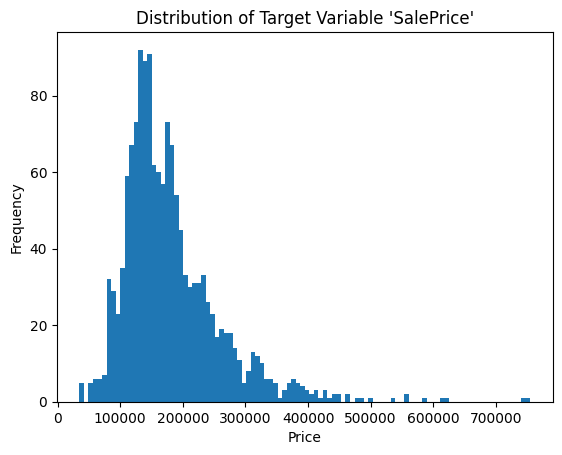

Skewness of SalePrice: 1.8829
Skewness of log-transformed SalePrice: 0.1213


In [3]:
# Learn more about target variable
print(df["SalePrice"].describe())

# Distribution of target variable
plt.hist(df["SalePrice"], bins=100)
plt.title("Distribution of Target Variable 'SalePrice'")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

print(f"Skewness of SalePrice: {df["SalePrice"].skew():.4f}") # -> right skewed

# Log transform
df["SalePrice_log"] = np.log1p(df["SalePrice"])
print(f"Skewness of log-transformed SalePrice: {df['SalePrice_log'].skew():.4f}")

### Remark

It is evident that the response variable is right-skewed. A log transformation is therefore applied to stabilise the distribution and reduce the skewness. This can be particularly helpful in linear models such as linear regression or ridge regression, as it stabilises the modelling and reduces the influence of outliers.

In [4]:
# Analyze percentage of missing values per feature
missing_percent = df.isna().mean().sort_values(ascending=False) * 100
print(missing_percent[missing_percent > 0])

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtFinType1     2.534247
BsmtCond         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [5]:
# Separate feature types
num_features = df.select_dtypes(include=["int64", "float64"]).columns
cat_features = df.select_dtypes(include=["object"]).columns

print(f"Number of Numerical Features: {len(num_features)}")
print(f"Number of Categorical Features: {len(cat_features)}")
#print(f"Numerical Features: {num_features}")
#print(f"Categorical Features: {cat_features}")

Number of Numerical Features: 39
Number of Categorical Features: 43


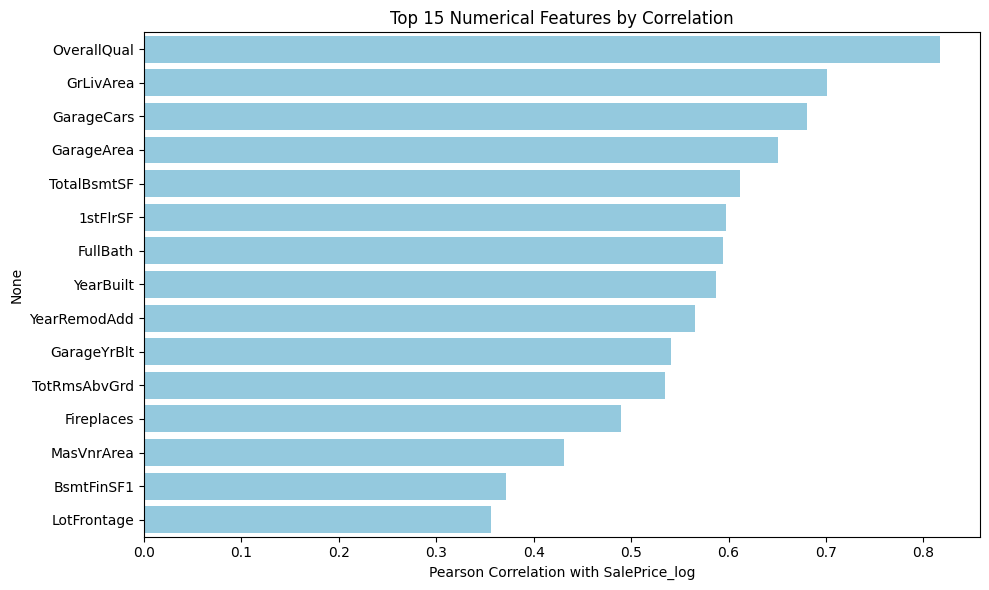

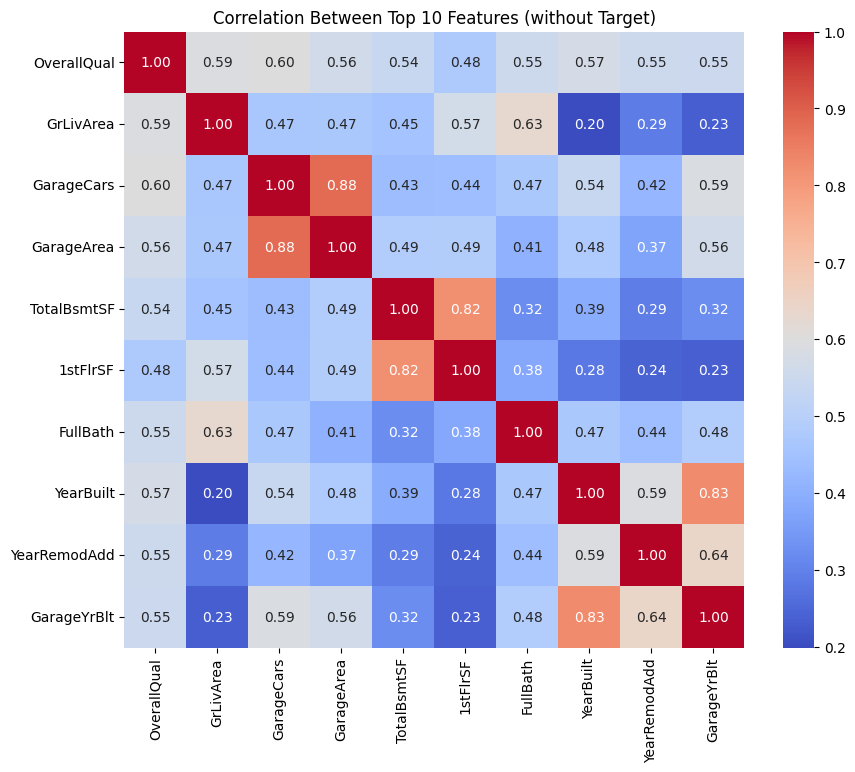

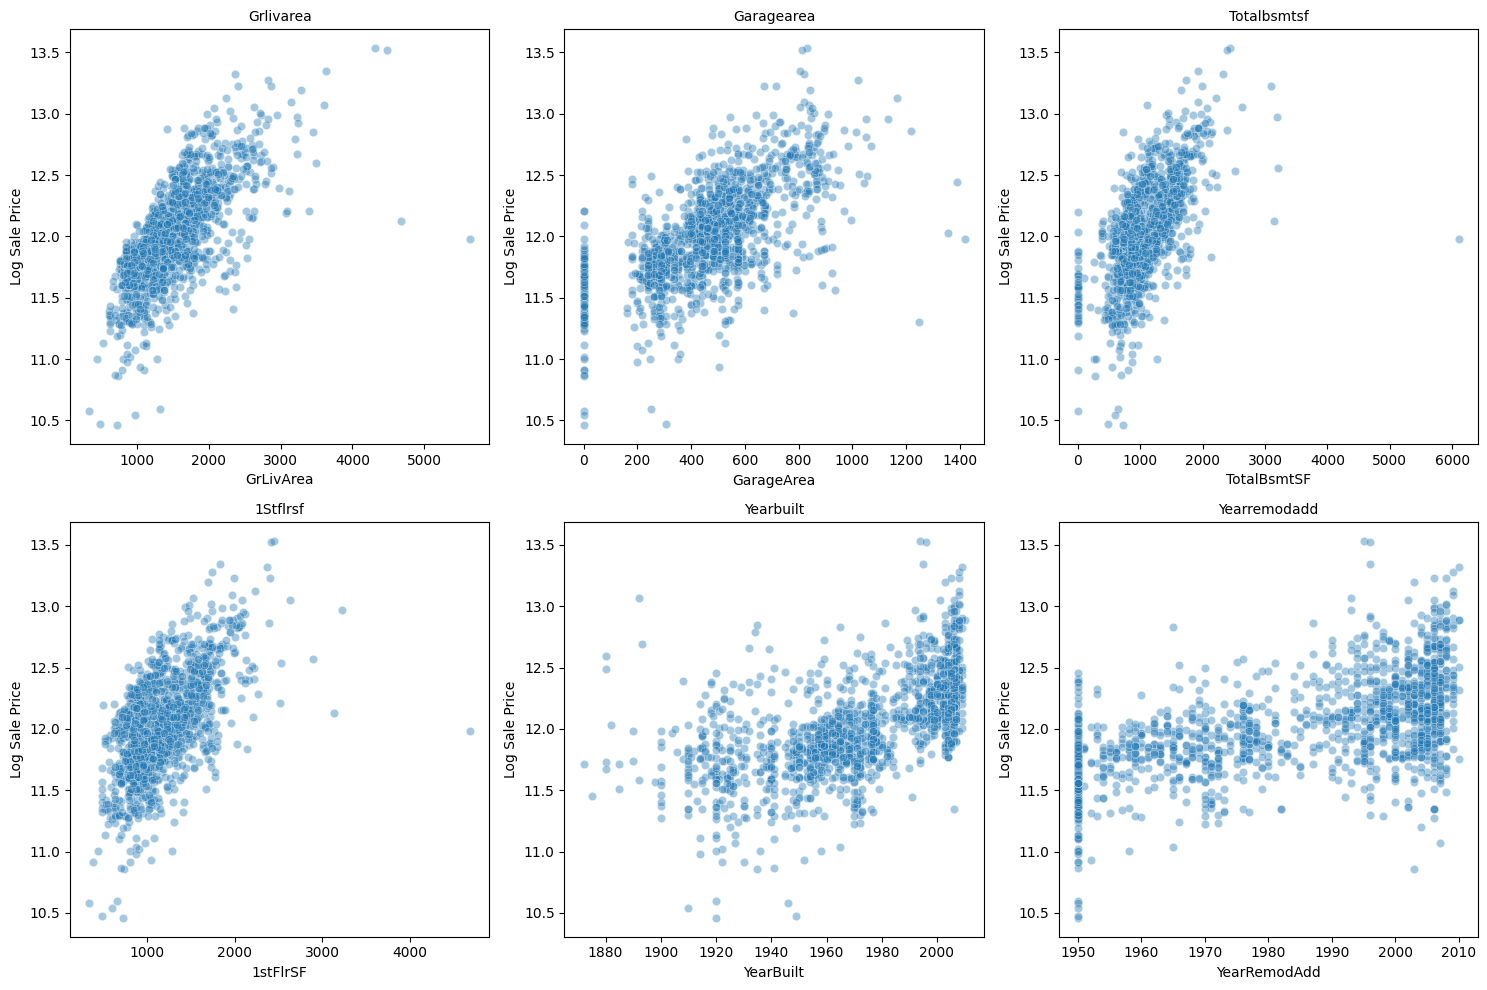

In [6]:
# Investigation of numerical features
num_features = df.select_dtypes(include=["int64", "float64"])
num_features_no_y = num_features.drop(columns=["SalePrice", "SalePrice_log"], errors="ignore")

# Correlation of numerical features with target variable
corr_matrix = num_features_no_y.join(df["SalePrice_log"]).corr()

# Correlation with Target Variable
corr_with_target = corr_matrix["SalePrice_log"].sort_values(ascending=False)

# Remove self correlation
corr_with_target = corr_with_target.drop("SalePrice_log")
#print('Top Correlations of Features with Target Variable:\n', corr_with_target.head(20))

top_corr = corr_with_target.head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_corr.values, y=top_corr.index, color="skyblue")  
plt.xlabel("Pearson Correlation with SalePrice_log")
plt.title("Top 15 Numerical Features by Correlation")
plt.tight_layout()
plt.show()


# Heatmap of top 10 numerical features 
top10 = corr_with_target.head(10).index
corr_top = df[top10].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_top, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Top 10 Features (without Target)")
plt.show()


# Scatterplots of top 6 numerical features and target variable
top6_num = ["GrLivArea", "GarageArea", "TotalBsmtSF", "1stFlrSF", "YearBuilt", "YearRemodAdd"]

plt.figure(figsize=(15, 10))

for i, col in enumerate(top6_num):
    plt.subplot(2, 3, i+1)
    
    sns.scatterplot(
        x=df[col],
        y=df["SalePrice_log"],
        alpha=0.4)
    
    plt.xlabel(col)
    plt.ylabel("Log Sale Price")
    plt.title(col.replace("_", " ").title(), fontsize=10)

plt.tight_layout()
plt.show()

### Remark

Initial correlations were explored on the full dataset to gain intuition.
Final feature selection and preprocessing steps were performed exclusively on the training data to avoid data leakage.

The scatter plots indicate a positive correlation between the selected features and the target variable. This suggests that higher feature values are generally associated with higher target values, supporting their predictive relevance for the modeling task.

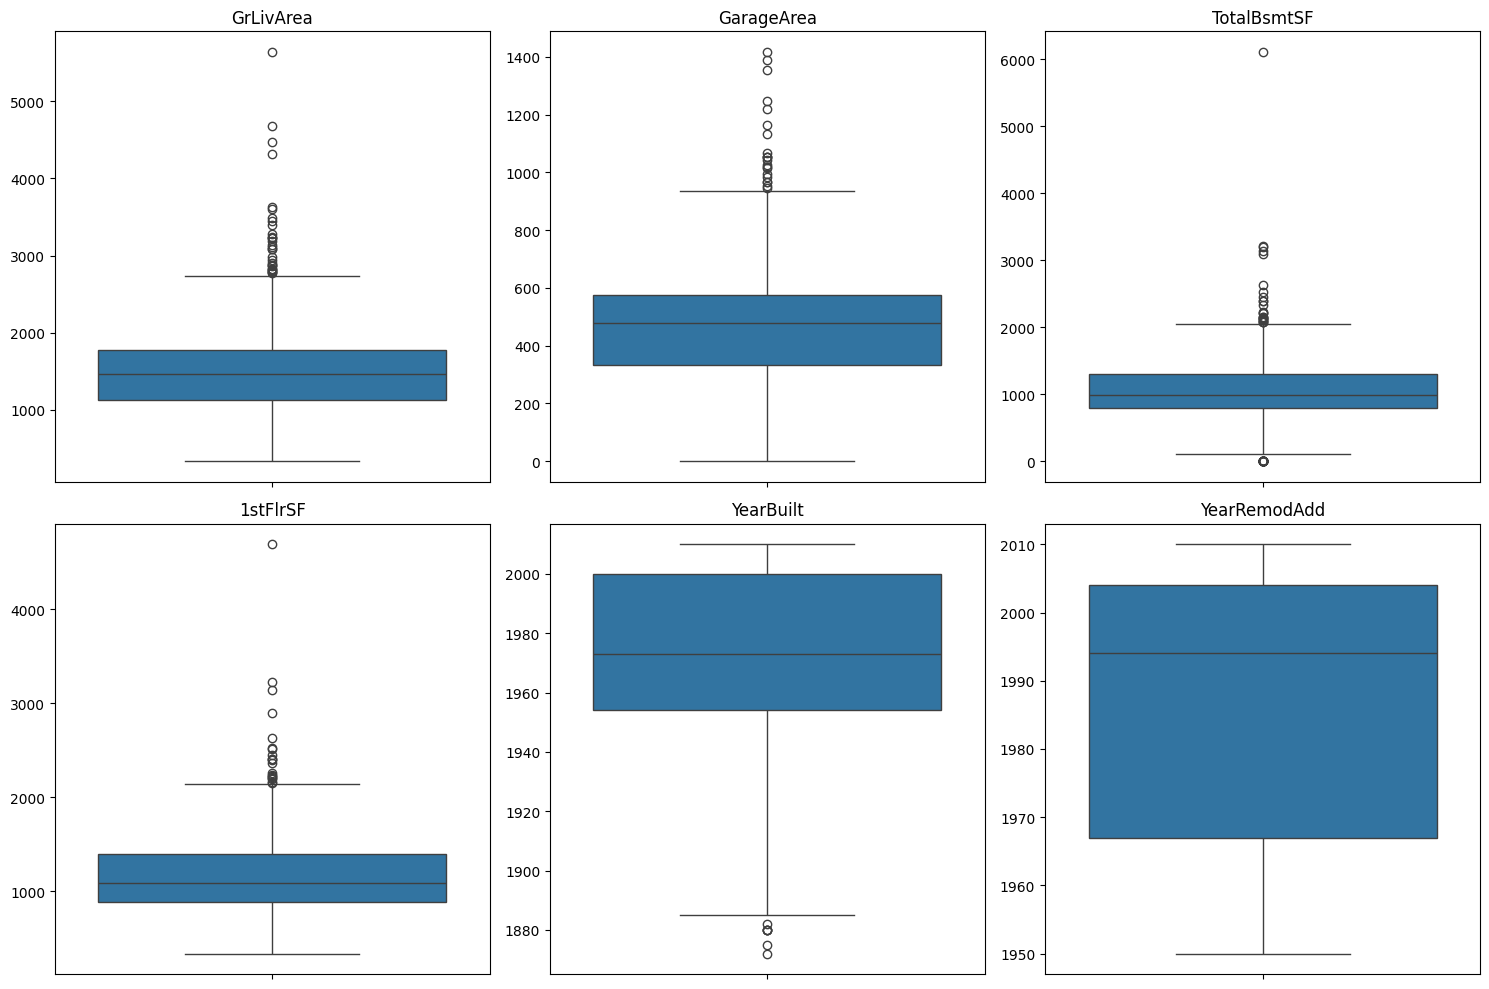

,TotalBsmtSF,GrLivArea,1stFlrSF,OverallQual
1298,6110,5642,4692,10
332,3206,1629,1629,8
496,3200,3228,3228,8
523,3138,4676,3138,10


In [7]:
# Investigation of outliers of numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top6_num):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel("")

for j in range(len(top6_num), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Explore if outliers are reasonable
df.sort_values("TotalBsmtSF", ascending=False)[
    ["TotalBsmtSF", "GrLivArea", "1stFlrSF", "OverallQual"]
].head(4)

### Remark

Outliers were analyzed in context with related features such as living area and overall quality. 
The extreme values were consistent with the dataset structure and therefore retained.

### Mutual Information
Next, the mutual information is computed to determine relevant features. MI is considered, even though the Pearson correlation has already been taken into account, because MI can also identify non-linear patterns.
Mutual Information quantifies how much information a feature contains about the target variable. Higher scores indicate stronger relevance for predicting house prices, regardless of linearity.

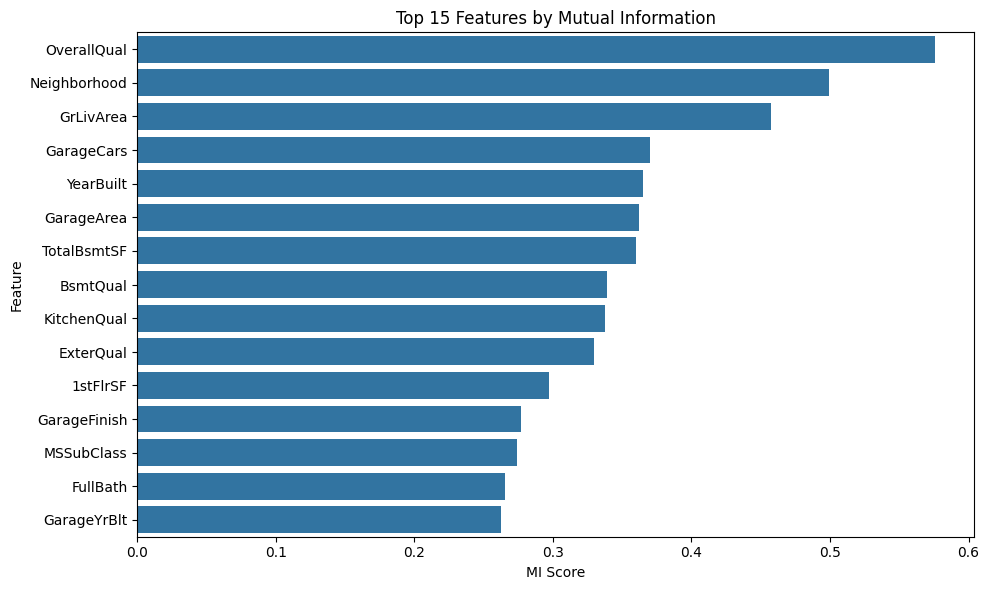

In [8]:
# Copy data
df_mi = df.copy()

# Target
y = df_mi["SalePrice_log"]

# Features
X = df_mi.drop(columns=["SalePrice_log", "SalePrice"])
# Fill missing values temporarily
X = X.fillna(-999)

# Encode categorial features
for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))


# Compute Mutual Information
mi_scores = mutual_info_regression(X, y, random_state=42)

# Convert into DataFrame 
mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
})

mi_df = mi_df.sort_values(by="MI Score", ascending=False)
#print(mi_df.head(15))

# Barplot of top 15 Features
top_mi = mi_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_mi, x="MI Score", y="Feature")

plt.title("Top 15 Features by Mutual Information")
plt.tight_layout()
plt.savefig("mi_top15.png", dpi=300) 
plt.show()

### Investigation of Categorial Features

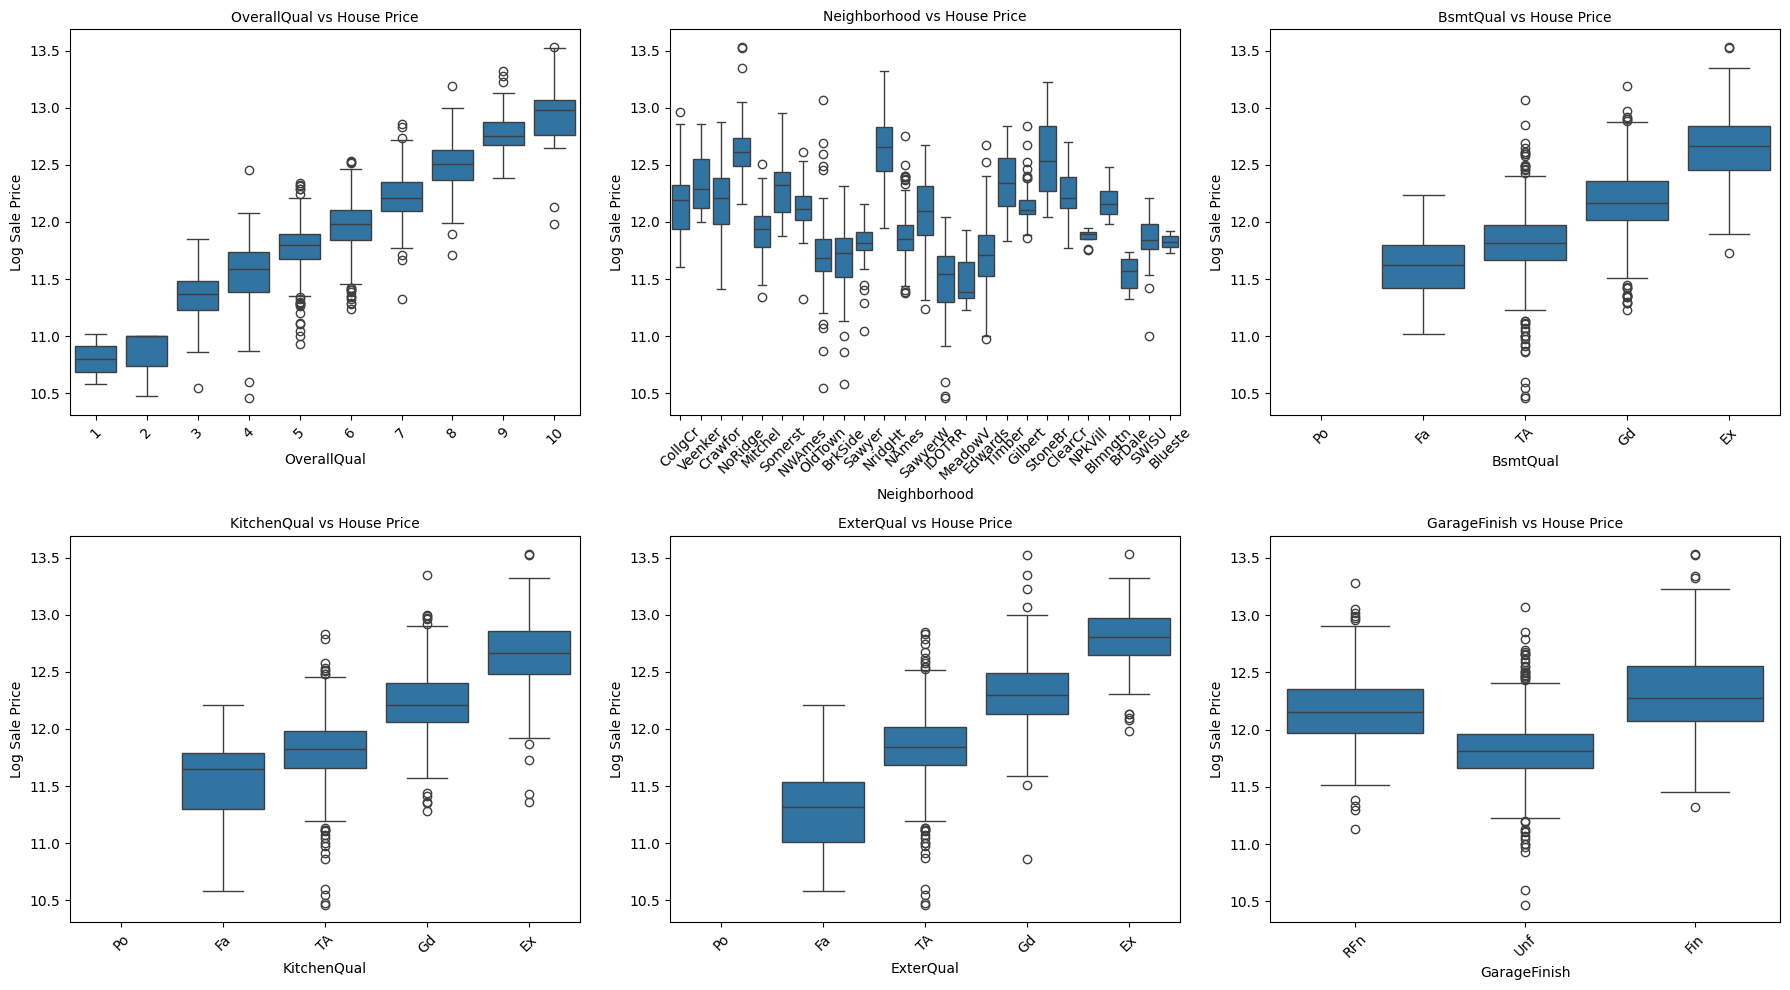

In [9]:
# Key categorical features 
key_cat_features = ["OverallQual", "Neighborhood", "BsmtQual", "KitchenQual", "ExterQual", "GarageFinish"]

order_dict = {"ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
              "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
              "BsmtQual": ["Po", "Fa", "TA", "Gd", "Ex"],}

# Create Boxplots
plt.figure(figsize=(18, 10))

for i, col in enumerate(key_cat_features):
    plt.subplot(2, 3, i+1)
    
    if col in order_dict:
        sns.boxplot(x=df[col], y=df["SalePrice_log"], order=order_dict[col])
    else:
        sns.boxplot(x=df[col], y=df["SalePrice_log"])
    
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel("Log Sale Price")
    plt.title(f"{col} vs House Price", fontsize=10)

plt.tight_layout()
plt.show()

### Remark

The boxplots display the target variable (SalePrice) on the y-axis across the categories of each feature on the x-axis. When the boxes show little overlap, it indicates that the feature has a strong influence on the target, which aligns with the high Mutual Information scores.

## Data Preprocessing

Approach
- Train/Test split
- Handling of missing values
- Scaling and encoding of features

In [10]:
#Train/Test split 80/20
X = df.drop(columns=["SalePrice", "SalePrice_log"])
y = df["SalePrice_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [11]:
# Handle missing values
# Drop features with missing values >80%
X_train.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence"], inplace=True)
X_test.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence"], inplace=True)

# Numerical features 
num_features = X_train.select_dtypes(include=["int64", "float64"]).columns

# Categorical features 
cat_features = X_train.select_dtypes(include=["object"]).columns

In [12]:
# Scaling/Encoding of features

#ordinal_features = [
#    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure",
#    "BsmtFinType1", "BsmtFinType2", "KitchenQual", "Functional", "FireplaceQu",
#    "HeatingQC", "GarageFinish", "GarageQual", "GarageCond", "GarageType" #"PoolQC"]
ordinal_mappings = {
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["Unf","LwQ","Rec","BLQ","ALQ","GLQ"],
    "BsmtFinType2": ["Unf","LwQ","Rec","BLQ","ALQ","GLQ"],
    "Functional": ["Sal","Sev","Maj2","Maj1","Mod","Min2","Min1","Typ"],
    "FireplaceQu": ["Po","Fa","TA","Gd","Ex"],
    "GarageFinish": ["Unf","RFn","Fin"],
    "GarageQual": ["Po","Fa","TA","Gd","Ex"],
    "GarageCond": ["Po","Fa","TA","Gd","Ex"],
    "GarageType": ["Basment","2Types","CarPort","Detchd","Attchd","BuiltIn"],
    "HeatingQC": ["Po","Fa","TA","Gd","Ex"],
}
ordinal_features = list(ordinal_mappings.keys())
# order of feature variations for ordinal transformer
categories_for_encoder = [ordinal_mappings[feat] for feat in ordinal_features]

#nominal_features = [
#    "MSZoning", "Street", "Alley", "LotShape", "LandContour", "Utilities", 
#    "LotConfig", "LandSlope", "Neighborhood", "Condition1", "Condition2", 
#    "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", 
#    "MasVnrType", "Foundation", "Heating", "CentralAir", "Electrical", "PavedDrive", 
#    "Fence", "MiscFeature", "SaleType", "SaleCondition"]
nominal_features = [col for col in cat_features if col not in ordinal_features]


# Numerical
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # Missing Value Handling
    ("scaler", StandardScaler())                    # Scaling of numerical variables
])

# Nominal
nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Ordinal 
ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=categories_for_encoder))
])

# Define ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("cat", nominal_transformer, nominal_features)
    ]
)

In [13]:
# Train/Test Preprocessing
preprocessor.fit(X_train)  # Training just on training data
X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

## Model Training, Hyperparameter Tuning and Evaluation

The following models were selected to cover different levels of model complexity, from simple linear baselines to advanced ensemble methods:

- Linear Regression (baseline)
- Ridge Regression (regularized baseline)
- Random Forest (bagging-based non-linear model)
- XGBoost (gradient boosting model)

### Baseline Model: Linear Regression

In [14]:
# Linear Regression
# Initialise model
lin_reg = LinearRegression()

# Training
lin_reg.fit(X_train_processed, y_train)

# Prediction
y_train_pred = lin_reg.predict(X_train_processed)
y_test_pred = lin_reg.predict(X_test_processed)

# Evaluation
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

print(f"Linear Regression:")
print(f"Train RMSE: {rmse_train:.4f}, R²: {r2_train:.4f}")
print(f"Test RMSE:  {rmse_test:.4f}, R²: {r2_test:.4f}")

Linear Regression:
Train RMSE: 0.0967, R²: 0.9387
Test RMSE:  0.1258, R²: 0.9152


In [15]:
models = {
    "LinearRegression": LinearRegression(),
}

cv_results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    
    cv_results[name] = -scores
    
    print(f"{name} Cross Validation:")
    print(f"  Mean RMSE: {-scores.mean():.4f}")
    print(f"  Std RMSE:  {scores.std():.4f}")

LinearRegression Cross Validation:
  Mean RMSE: 0.1563
  Std RMSE:  0.0336


### Hyperparameter Tuning: Ridge Regression & Random Forest & XGBoost

In [ ]:
# Pipeline with preprocessing and ridge regression
pipe_ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

param_grid_ridge = {
    'model__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]
}

grid_search_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search_ridge.fit(X_train, y_train)
print("Best Hyperparameter:", grid_search_ridge.best_params_)

cv = grid_search_ridge.cv_results_
best_idx = grid_search_ridge.best_index_

mean_rmse = -cv["mean_test_score"][best_idx]
std_rmse  = cv["std_test_score"][best_idx]

print("Best CV Mean RMSE:", mean_rmse)
print("Best CV Std RMSE:", std_rmse)


# Result of the model using best parameters
best_ridge = grid_search_ridge.best_estimator_

# Evaluation using best parameters
y_train_pred_ridge = best_ridge.predict(X_train)
y_test_pred_ridge  = best_ridge.predict(X_test)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
rmse_test_ridge  = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))

r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
r2_test_ridge  = r2_score(y_test, y_test_pred_ridge)

print(f"Ridge Regression (with best Hyperparameter):")
print(f"Train RMSE: {rmse_train_ridge:.4f}, R²: {r2_train_ridge:.4f}")
print(f"Test RMSE:  {rmse_test_ridge:.4f}, R²: {r2_test_ridge:.4f}")

In [ ]:
# Pipeline with preprocessing and Random Forest
pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Hyperparameter for GridSearchCV
param_grid_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

# Grid search
grid_search_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Training
grid_search_rf.fit(X_train, y_train)

# Best hyperparameter
print("Best Hyperparameter:", grid_search_rf.best_params_)

cv = grid_search_rf.cv_results_
best_idx = grid_search_rf.best_index_

mean_rmse = -cv["mean_test_score"][best_idx]
std_rmse  = cv["std_test_score"][best_idx]

print("Best CV Mean RMSE:", mean_rmse)
print("Best CV Std RMSE:", std_rmse)


# Model with best hyperparameters
best_rf = grid_search_rf.best_estimator_

# Preditction
y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf  = best_rf.predict(X_test)

# Evaluation
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rmse_test_rf  = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf  = r2_score(y_test, y_test_pred_rf)

print(f"Random Forest (with best Hyperparameter):")
print(f"Train RMSE: {rmse_train_rf:.4f}, R²: {r2_train_rf:.4f}")
print(f"Test RMSE:  {rmse_test_rf:.4f}, R²: {r2_test_rf:.4f}")

In [ ]:
# XGBoost Model
xgb = XGBRegressor(
    objective='reg:squarederror',  # Regression
    random_state=42,
    n_jobs=-1
)

# Hyperparameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# Pipeline: Preprocessing + Model
pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb)
])

# GridSearchCV 
grid_search_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Training
grid_search_xgb.fit(X_train, y_train)

# Best parameter, cross validation RMSE
print("Best Hyperparameters:", grid_search_xgb.best_params_)

cv = grid_search_xgb.cv_results_
best_idx = grid_search_xgb.best_index_

mean_rmse = -cv["mean_test_score"][best_idx]
std_rmse  = cv["std_test_score"][best_idx]

print("Best CV Mean RMSE:", mean_rmse)
print("Best CV Std RMSE:", std_rmse)

# Evaluate model with best parameters
best_xgb = grid_search_xgb.best_estimator_

# Prediction on X_train / X_test
y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb  = best_xgb.predict(X_test)

# Evaluation
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
rmse_test_xgb  = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
r2_train_xgb = r2_score(y_train, y_train_pred_xgb)
r2_test_xgb  = r2_score(y_test, y_test_pred_xgb)

print("\nXGBoost Evaluation:")
print(f"Train RMSE: {rmse_train_xgb:.4f}, R²: {r2_train_xgb:.4f}")
print(f"Test RMSE:  {rmse_test_xgb:.4f}, R²: {r2_test_xgb:.4f}")

### Model Comparison

In this section, different models were trained and evaluated on the log-transformed `SalePrice`:

1. **Linear Regression** – baseline linear model  
2. **Ridge Regression** – linear model with L2 regularization  
3. **Random Forest** – non-linear ensemble model used as a benchmark  
4. **XGBoost Regressor** – gradient boosting model for capturing complex non-linear relationships

**Evaluation metrics:**
- **RMSE**: Root Mean Squared Error – measures average prediction error magnitude (in log-price units)  
- **R²**: Coefficient of Determination – proportion of variance in the target explained by the model  

---

#### Results Overview (Train/Test Split)

| Model                 | Train RMSE | Test RMSE | Train R² | Test R² | 
|-----------------------|------------|-----------|----------|---------|
| Linear Regression     | 0.0967     | 0.1258    | 0.9387   | 0.9152  | 
| Ridge Regression      | 0.1137     | 0.1326    | 0.9151   | 0.9057  | 
| Random Forest         | 0.0536     | 0.1538    | 0.9812   | 0.8732  | 
| XGBoost               | 0.0507     | 0.1288    | 0.9832   | 0.9111  |

#### Key Insights (Train/Test)

- **Linear vs. Ridge:**  
  Ridge slightly reduces training performance due to L2 regularization, while maintaining similar test performance compared to Linear Regression.

- **Random Forest:**  
  Very strong training performance indicates high model capacity, but the larger gap to test performance suggests overfitting.

- **XGBoost:**  
  Achieves the best test performance among all models while also maintaining very strong training accuracy. This indicates an excellent balance between model complexity and generalization ability, making it the strongest overall model in this comparison.

- **Overall:**  
  Linear models already achieve strong and stable performance on this dataset, despite their simplicity. However, boosting methods—especially XGBoost—clearly outperform the other non-linear models in terms of predictive accuracy and generalization.

---

### Cross-Validation Results

Cross-validation (CV) provides a more robust estimate of model performance than a single train/test split, as it averages results over multiple folds and is therefore better suited for model comparison.

| Model              | CV Mean RMSE | CV Std RMSE |
|-------------------|--------------|-------------|
| Linear Regression  | 0.1563       | 0.0336      |
| Ridge Regression   | 0.1448       | 0.0309      |
| Random Forest      | 0.1434       | 0.0180      |
| XGBoost            | 0.1242       | 0.0129      |

---

#### Key Insights (Cross-Validation)

- **Linear vs. Ridge:**  
  Ridge consistently improves performance and stability compared to Linear Regression, as reflected in a lower CV RMSE and slightly reduced variance across folds.

- **Random Forest:**  
  Improves over linear models and shows relatively stable performance (low standard deviation), but is outperformed by boosting methods.

- **XGBoost:**  
  Achieves the best cross-validation performance with the lowest CV RMSE and the lowest standard deviation across all models. This indicates both high predictive accuracy and strong robustness across different folds.

- **Overall:**  
  Cross-validation confirms that non-linear models outperform linear approaches on this dataset. Among them, XGBoost clearly provides the best balance of accuracy and stability, making it the strongest model in this comparison.


## Feature Engineering

In [16]:
# Train/Test Split
X = df.drop(columns=["SalePrice", "SalePrice_log"])
y = df["SalePrice_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Drop Columns 
drop_cols = ["PoolQC", "MiscFeature", "Alley", "Fence"]
X_train = X_train.drop(columns=drop_cols)
X_test  = X_test.drop(columns=drop_cols)

# Feature Engineering Function
def add_features(X):
    X = X.copy()
    X['TotalArea'] = X['GrLivArea'] + X['BsmtFinSF1'] + X['BsmtFinSF2']
    X['TotalBathrooms'] = X['FullBath'] + 0.5*X['HalfBath']
    X['QualityIndex'] = X['ExterQual'].map({'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5}) + \
                        X['KitchenQual'].map({'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5})
    X['Quality*Area'] = X['OverallQual'] * X['GrLivArea']
    return X

# Feature Engineering 
X_tmp = add_features(X_train)

# Determine feature typen 
num_features = X_tmp.select_dtypes(include=["int64", "float64"]).columns
cat_features = X_tmp.select_dtypes(include=["object"]).columns

ordinal_features = list(ordinal_mappings.keys())
nominal_features = [col for col in cat_features if col not in ordinal_features]

feature_transformer = FunctionTransformer(add_features)


preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("cat", nominal_transformer, nominal_features)
    ]
)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=10, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        max_features='sqrt',
        min_samples_leaf=1,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        subsample=0.7,
        colsample_bytree=0.7,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )
}

In [17]:
cv_results = {}

# Cross Validation with Feature Engineering and Preprocessing
for name, model in models.items():
    pipe = Pipeline([
        ("feature_engineering", feature_transformer),
        ("preprocessor", preprocessor_fe),
        ("model", model)
    ])
    
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    
    cv_results[name] = -scores
    
    print(f"{name} Cross Validation with Feature Engineering:")
    print(f"  Mean RMSE: {-scores.mean():.4f}")
    print(f"  Std RMSE:  {scores.std():.4f}")

LinearRegression Cross Validation with Feature Engineering:
  Mean RMSE: 0.1531
  Std RMSE:  0.0290
Ridge Cross Validation with Feature Engineering:
  Mean RMSE: 0.1417
  Std RMSE:  0.0299
RandomForest Cross Validation with Feature Engineering:
  Mean RMSE: 0.1375
  Std RMSE:  0.0182
XGBoost Cross Validation with Feature Engineering:
  Mean RMSE: 0.1265
  Std RMSE:  0.0108


## Model Performance Summary

The table below summarizes **Cross-Validation (CV) RMSE** for baseline models before and after feature engineering. For Ridge Regression, Random Forest and XGBoost the optimised hyperparameters were used.


#### Performance (CV Mean RMSE)
| Model              | No FE | With FE |
|-------------------|------|--------|
| Linear Regression  | 0.1563 | 0.1531 |
| Ridge Regression   | 0.1448 | 0.1417 |
| Random Forest      | 0.1434 | 0.1375 |
| XGBoost            | 0.1242 | 0.1265 |

#### Stability (CV Std RMSE)
| Model              | No FE | With FE |
|-------------------|------|--------|
| Linear Regression  | 0.0336 | 0.0290 |
| Ridge Regression   | 0.0309 | 0.0299 |
| Random Forest      | 0.0180 | 0.0182 |
| XGBoost            | 0.0129 | 0.0108 |

### Conclusions

Feature engineering leads to **consistent but model-dependent effects** on cross-validation performance.

- **Linear Regression** shows only marginal improvements, suggesting that the engineered features add limited additional linear signal.

- **Ridge Regression** benefits slightly more, achieving a lower CV RMSE and slightly reduced variance across folds, indicating improved generalization through regularization.

- **Random Forest** shows consistent improvements in CV performance, suggesting that the engineered features enhance nonlinear interactions captured by the model.

- **XGBoost** is the only model where feature engineering does not improve predictive performance. The slight increase in CV RMSE suggests that the original feature set already contains most of the predictive signal, while the engineered features may introduce redundancy or noise. However, the reduced standard deviation indicates slightly improved stability across folds.

Overall, feature engineering has a **moderate and mixed impact** on model performance. While linear and tree-based models benefit to some extent, XGBoost performance slightly deteriorates, indicating that more complex models may already extract sufficient structure from the original features. The most consistent effect across all models is a small reduction in variance, suggesting improved stability across cross-validation folds.

## Model Interpretation and Error Analysis

In [18]:
predictions = {}

for name, model in models.items():
    pipe = Pipeline([
        ("feature_engineering", feature_transformer),
        ("preprocessor", preprocessor_fe),
        ("model", model)
    ])
    
    # Train auf Trainingsdaten
    pipe.fit(X_train, y_train)
    
    # Predictions
    y_test_pred = pipe.predict(X_test)
    
    predictions[name] = {
        "model": pipe,
        "y_test_pred": y_test_pred
    }

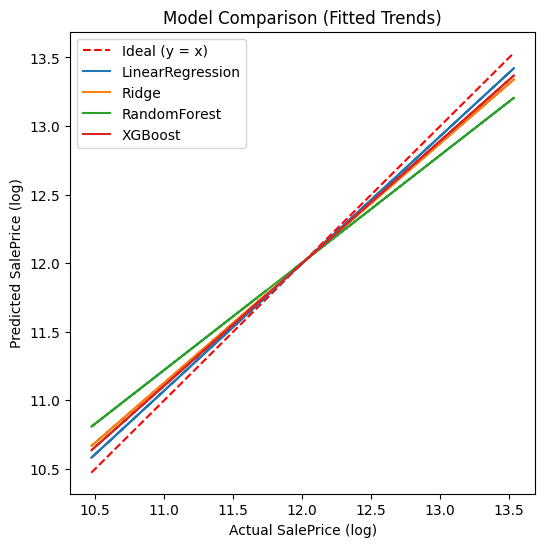

In [19]:
plt.figure(figsize=(6,6))

# Ideal line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Ideal (y = x)"
)

for name, result in predictions.items():
    reg = LinearRegression()
    reg.fit(y_test.values.reshape(-1,1), result["y_test_pred"])
    y_fit = reg.predict(y_test.values.reshape(-1,1))

    plt.plot(y_test, y_fit, label=name)

plt.xlabel("Actual SalePrice (log)")
plt.ylabel("Predicted SalePrice (log)")
plt.title("Model Comparison (Fitted Trends)")
plt.legend()
plt.show()

#### Remark
The linear model appears visually closer to the ideal line, but performance should be evaluated using error metrics such as RMSE and R². More flexible models like XGBoost may capture nonlinear patterns better, even if the visual fit appears less smooth.

While RMSE provides a global performance metric, the line plot helps to understand systematic deviations from the ideal prediction. It reveals whether models tend to over- or under-predict across the target range and how closely their overall trend aligns with the perfect prediction line.

In trend-based visualizations, errors can appear to cancel each other out. For example, if the model overpredicts by +200 in some cases and underpredicts by −200 in others, the overall trend may still look close to the ideal line. However, this is only a visual effect and does not reflect true prediction accuracy. Metrics like RMSE or MSE do not allow such cancellation.

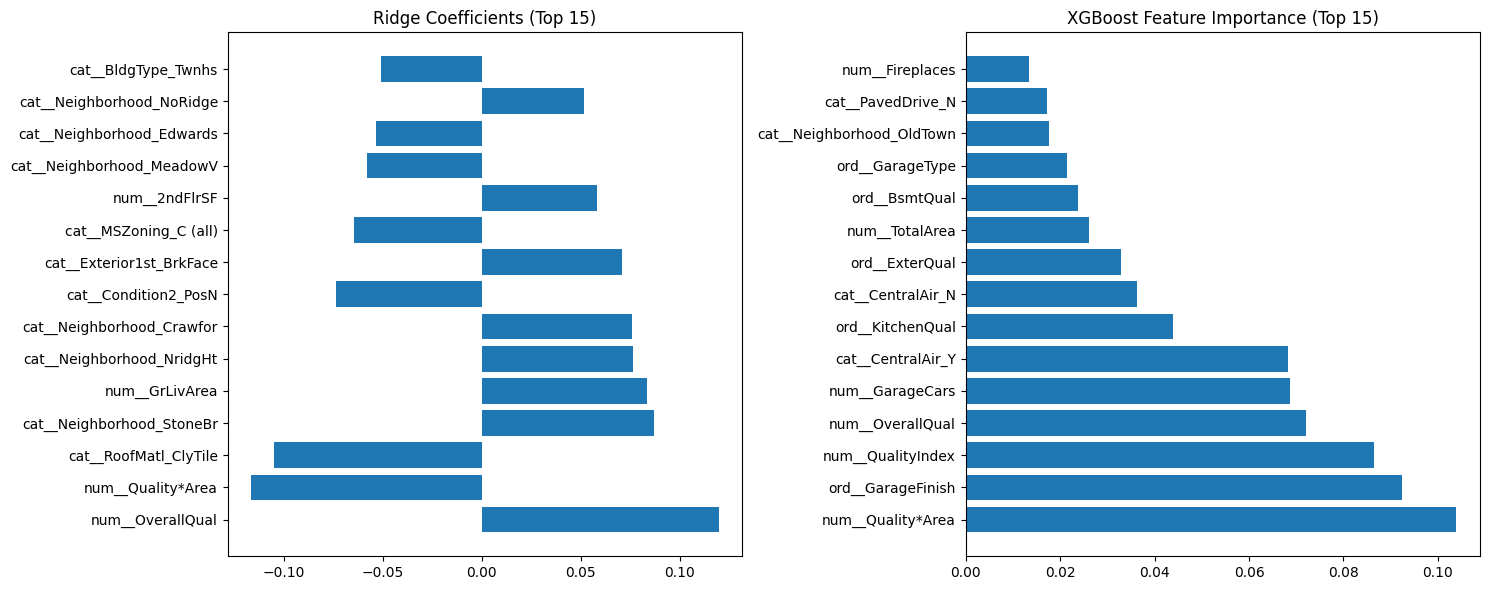

In [20]:
# Feature names from preprocessor
xgb_model = predictions["XGBoost"]["model"]
feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()

# Ridge Model
ridge_pipe = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor_fe),
    ("model", models["Ridge"])
])

ridge_pipe.fit(X_train, y_train)
ridge_coefs = ridge_pipe.named_steps["model"].coef_

# XGBoost Importance
xgb_importance = xgb_model.named_steps["model"].feature_importances_

# Plot
top_n = 15

plt.figure(figsize=(15,6))

# Ridge
plt.subplot(1,2,1)
top_idx = np.argsort(np.abs(ridge_coefs))[-top_n:]
plt.barh(range(top_n), ridge_coefs[top_idx])
plt.yticks(range(top_n), feature_names[top_idx])
plt.gca().invert_yaxis()
plt.title("Ridge Coefficients (Top 15)")

# XGBoost
plt.subplot(1,2,2)
top_idx = np.argsort(xgb_importance)[-top_n:]
plt.barh(range(top_n), xgb_importance[top_idx])
plt.yticks(range(top_n), feature_names[top_idx])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance (Top 15)")

plt.tight_layout()
plt.show()

#### Conclusion

- Feature engineering proved effective, with newly created variables such as *QualityIndex* and *Quality*Area* ranking among the most important predictors.  
- House quality and living area are consistently identified as the strongest drivers of house price prediction across all models.  
- XGBoost effectively combines numerical and categorical information, resulting in strong predictive performance.  
- Linear models such as Ridge capture similar global patterns but differ from tree-based models like Random Forest and XGBoost, which are better at modelling nonlinear relationships and feature interactions.

### SHAP Plots for XGBoost

In this section, we analyze the contributions of individual features to the model predictions using SHAP (SHapley Additive exPlanations). SHAP values provide a consistent and interpretable way to quantify how each feature impacts the predicted outcome. By visualizing these effects with summary and dependence plots, we can understand both the global importance of features and how specific features interact with the prediction, which helps to interpret and validate the XGBoost model.

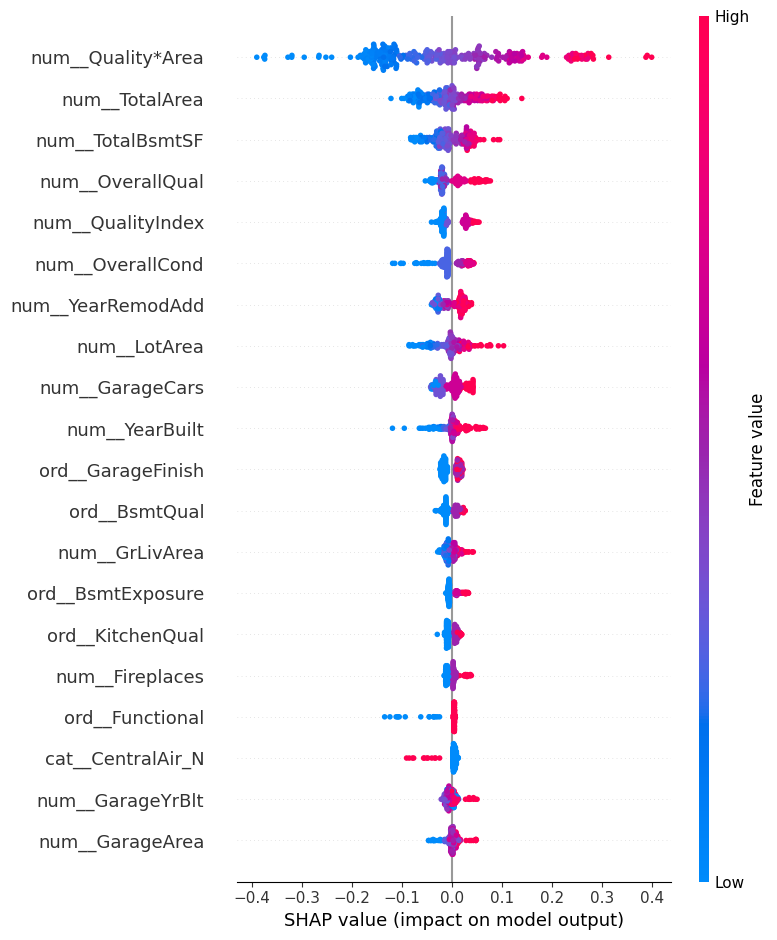

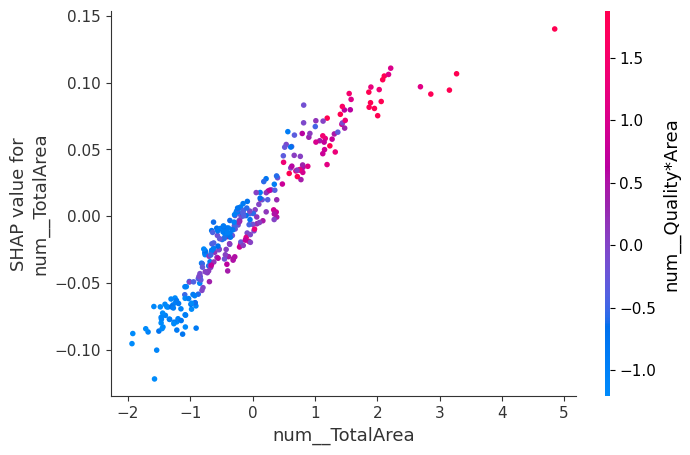

In [21]:
# Apply feature engineering to the test data
X_test_fe = add_features(X_test)  # using your previously defined add_features function

# Apply preprocessing (numerical, ordinal, nominal transformations)
X_test_transformed = xgb_model.named_steps['preprocessor'].transform(X_test_fe)

# Create SHAP explainer for the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model.named_steps['model'])

# Compute SHAP values (using the sample to reduce computation time)
shap_values = explainer.shap_values(X_test_transformed)

# Get feature names after preprocessing
all_features = xgb_model.named_steps['preprocessor'].get_feature_names_out()

# Summary plot (dot plot for detailed feature effects)
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_features)

# Dependence plot for a specific feature
shap.dependence_plot("num__TotalArea", shap_values, X_test_transformed, feature_names=all_features)

#### SHAP Summary Plot

The SHAP summary plot illustrates the global impact of each feature on the model’s predictions. Features are ordered by their overall importance, measured as the mean absolute SHAP value.

Each point represents an individual observation. The position on the x-axis indicates whether the feature contributes positively or negatively to the prediction, while the color encodes the feature value (red = high, blue = low).

The most influential feature is the interaction term Quality × Area, which shows a strong and consistent positive relationship with the target variable. High values of this feature (large, high-quality houses) significantly increase the predicted outcome, while low values decrease it.

Overall area-related features such as TotalArea and GrLivArea also have a strong positive impact, although their effects are more dispersed, indicating interactions with other variables. Quality-related features (e.g., OverallQual, KitchenQual, and BsmtQual) display clear monotonic patterns, where higher quality consistently leads to higher predictions.

Some features, such as LotArea and YearBuilt, exhibit a wider spread of SHAP values, suggesting non-linear effects or dependencies on other features. In contrast, lower-ranked features (e.g., CentralAir_N and OpenPorchSF) have minimal influence, as their SHAP values are concentrated around zero.

Overall, the model is primarily driven by property size and quality, with secondary contributions from structural and temporal features, reflecting realistic drivers of housing prices.

#### SHAP Dependence Plot

The SHAP dependence plot for TotalArea reveals a clear positive relationship between total area and the model prediction. Higher values of TotalArea are associated with positive SHAP values, indicating that larger properties increase the predicted outcome.

However, the relationship is not strictly linear. The curve suggests a non-linear pattern with diminishing marginal effects: increases in TotalArea have a stronger impact at lower to mid ranges, while the effect gradually flattens for larger values. This indicates diminishing returns, where additional area contributes less to the prediction at higher levels.

Furthermore, the interaction with the feature Quality × Area highlights that the impact of total area is amplified when combined with higher quality. This suggests that size and quality jointly drive the model predictions rather than acting independently.

### Assessment of Model Quality

Residual plots are a key diagnostic tool for evaluating regression models. They show the difference between the predicted and actual values and help assess whether a model’s assumptions are reasonably satisfied.

By inspecting residual plots, several important aspects of model quality can be evaluated:

- Randomness of errors: Ideally, residuals should be randomly scattered around zero without visible patterns. This indicates that the model captures the underlying structure in the data well.
- Bias in predictions: Systematic deviations above or below zero may indicate that the model consistently over- or under-predicts in certain regions.
- Homoskedasticity (constant variance): The spread of residuals should be roughly constant across all predicted values. If the variance increases or decreases with the magnitude of predictions, this suggests heteroskedasticity.
- Non-linearity: Structured patterns (e.g., curves or funnels) in the residuals can indicate that important non-linear relationships are not captured by the model.

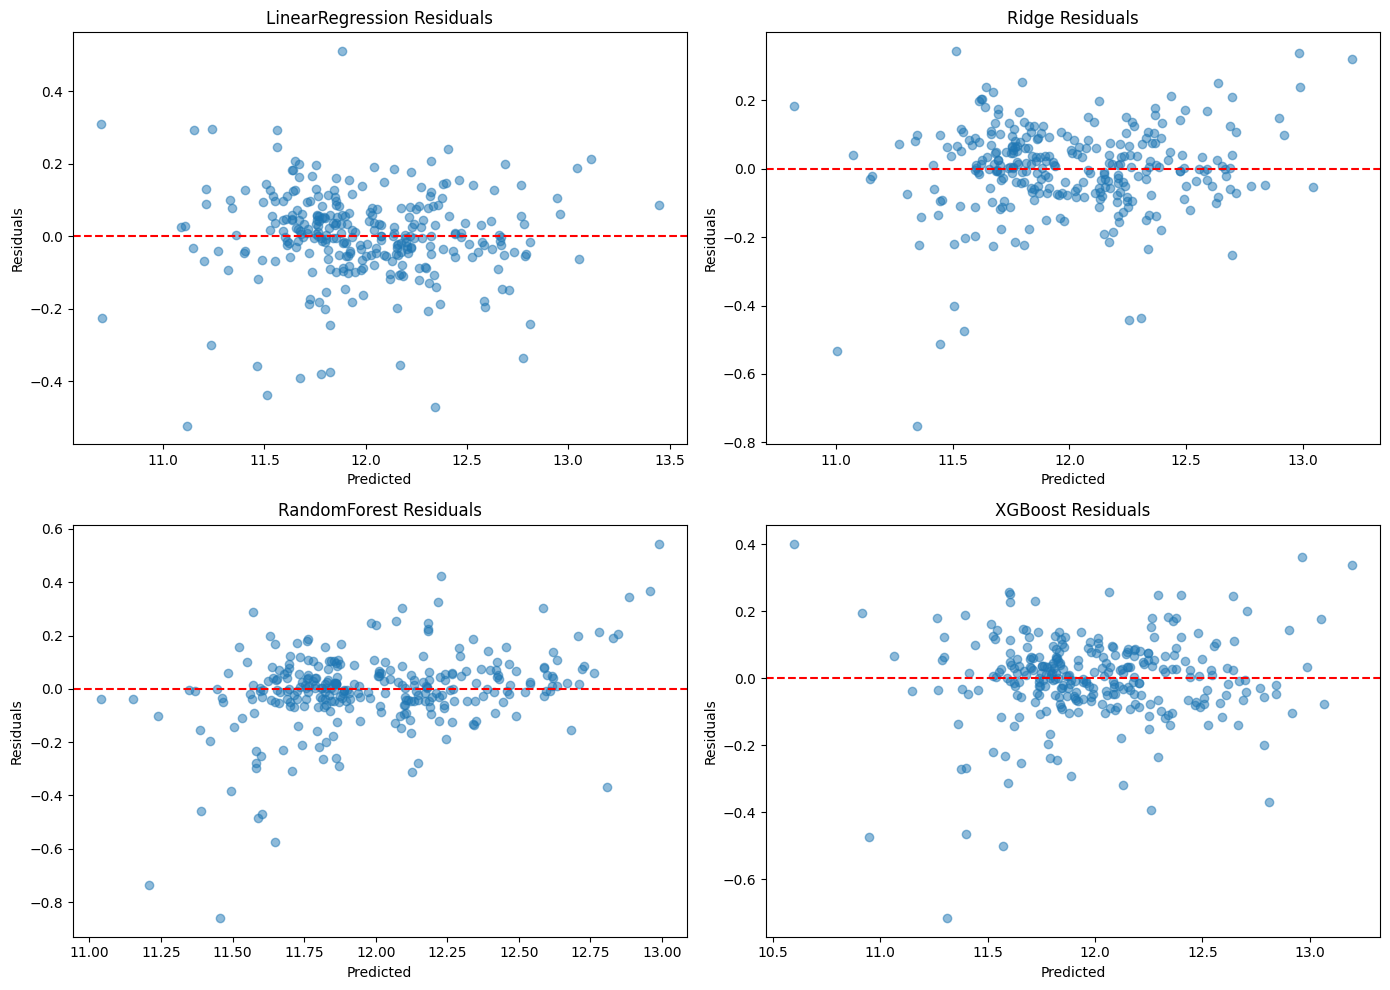

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()  # macht aus 2x2 ein flaches Array

for i, name in enumerate(predictions.keys()):
    y_pred = predictions[name]["y_test_pred"]
    residuals = y_test - y_pred

    axes[i].scatter(y_pred, residuals, alpha=0.5)
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f"{name} Residuals")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

### Remark

#### Linear Regression
- The residual plot of the Linear Regression model shows a relatively uniform scatter of residuals around zero. Compared to the other models, the error distribution appears more balanced, with no strong systematic structure or pronounced directional bias. This suggests that the model provides a stable average fit across the full range of predictions.

- However, a closer inspection indicates that the variance of the residuals is not perfectly constant, with slightly larger deviations at the lower and upper ends of the prediction range. While the model appears well-behaved in terms of overall error distribution, this also reflects its tendency to smooth out complex patterns in the data. As a result, it may achieve stability at the cost of not capturing more detailed non-linear relationships.

#### Ridge Regression
- The residuals of the Ridge Regression model are generally centered around zero, indicating no strong systematic bias in the predictions.
- However, the spread of the residuals is not constant across all predicted values. In particular, the variance of the errors is smaller for mid-range values and increases for both lower and higher values. This suggests the presence of heteroskedasticity, meaning that the assumption of constant error variance is not fully satisfied.
- While the model captures the main linear relationships in the data, it appears less accurate at the extremes of the target distribution. This indicates that additional non-linear features or more flexible models could potentially improve performance.


#### Random Forest
- The residual plot of the Random Forest model shows a clear structure rather than a random scatter around zero. Smaller predicted values are associated with negative residuals, while larger predicted values tend to show positive residuals. This indicates a systematic error pattern, suggesting that the model underestimates low values and overestimates high values.

- This pattern implies that the model does not fully capture the underlying relationship between features and target variable in a balanced way across the entire value range. While Random Forest is capable of modelling non-linear interactions, this result suggests that its predictions may still exhibit bias in certain regions of the target distribution.

#### XGBoost
- The residuals are roughly centered around zero with no strong systematic pattern, suggesting that the model captures the main relationships in the data reasonably well.
- For lower-priced houses, the model tends to produce larger negative residuals, indicating a tendency to overestimate prices in this segment.
- There are indications of increasing variance in residuals for extreme price ranges, suggesting mild heteroskedasticity.